In [84]:
!pip install ultralytics kaggle

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "name"
os.environ['KAGGLE_KEY'] = "7b14ccced06KEY_here"

In [86]:
!kaggle datasets list | head -n 5

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          16177        353                1  
hassanali789/world-happiness-report-2026-official-rankings          World Happiness Report 2026 — Official Rankings           3311  2026-04-29 02:35:36.353000            601         30                1  
patelris/steam-top-1495-games-dataset                               🎮 Steam Dataset for Recommendation & Prediction         345215  2026-04-29 13:56:22.557000            560         26

In [87]:
!kaggle datasets download -d mitangshu11/indian-roads-dataset

Dataset URL: https://www.kaggle.com/datasets/mitangshu11/indian-roads-dataset
License(s): unknown
indian-roads-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip indian-roads-dataset.zip -d data_temp

Archive:  indian-roads-dataset.zip
replace data_temp/Dataset3Class/AN_unpaved_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [83]:
!ls -R | head -n 100

.:
app.py
dataset
datasets
data_temp
data.yaml
indian-roads-dataset.zip
project.zip
runs
sample_data
training_backup.csv
yolo11n.pt
yolo26n.pt

./dataset:
images
labels

./dataset/images:
train
val

./dataset/images/train:
AN_unpaved_0.jpg
AN_unpaved_101.jpg
AN_unpaved_103.jpg
AN_unpaved_104.jpg
AN_unpaved_109.jpg
AN_unpaved_110.jpg
AN_unpaved_111.jpg
AN_unpaved_112.jpg
AN_unpaved_113.jpg
AN_unpaved_114.jpg
AN_unpaved_115.jpg
AN_unpaved_116.jpg
AN_unpaved_117.jpg
AN_unpaved_119.jpg
AN_unpaved_11.jpg
AN_unpaved_120.jpg
AN_unpaved_121.jpg
AN_unpaved_122.jpg
AN_unpaved_123.jpg
AN_unpaved_124.jpg
AN_unpaved_125.jpg
AN_unpaved_126.jpg
AN_unpaved_127.jpg
AN_unpaved_128.jpg
AN_unpaved_129.jpg
AN_unpaved_12.jpg
AN_unpaved_130.jpg
AN_unpaved_131.jpg
AN_unpaved_132.jpg
AN_unpaved_133.jpg
AN_unpaved_134.jpg
AN_unpaved_135.jpg
AN_unpaved_136.jpg
AN_unpaved_137.jpg
AN_unpaved_138.jpg
AN_unpaved_139.jpg
AN_unpaved_13.jpg
AN_unpaved_140.jpg
AN_unpaved_141.jpg
AN_unpaved_142.jpg
AN_unpaved_144.jpg
AN_

In [ ]:
import os

base = "dataset"
dirs = [
    f"{base}/images/train",
    f"{base}/images/val",
    f"{base}/labels/train",
    f"{base}/labels/val"
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

In [ ]:
import os
import random
import shutil

source = "data_temp/Dataset3Class"

images = [f for f in os.listdir(source) if f.endswith(".jpg")]
random.shuffle(images)

split = int(0.8 * len(images))
train_imgs = images[:split]
val_imgs = images[split:]

def move(files, split_type):
    count = 0
    for f in files:
        img_src = f"{source}/{f}"
        lbl_src = f"{source}/{f.replace('.jpg','.txt')}"

        if not os.path.exists(lbl_src):
            continue

        shutil.copy(img_src, f"dataset/images/{split_type}/{f}")
        shutil.copy(lbl_src, f"dataset/labels/{split_type}/{f.replace('.jpg','.txt')}")
        count += 1

    print(f"{split_type} done:", count)

move(train_imgs, "train")
move(val_imgs, "val")

In [ ]:
import os

print("Train images:", len(os.listdir("dataset/images/train")))
print("Val images:", len(os.listdir("dataset/images/val")))

In [ ]:
yaml_content = """
path: dataset
train: images/train
val: images/val

names:
  0: speed_breaker
  1: pothole
  2: unpaved_road
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

In [73]:
from ultralytics import YOLO
import os

# Check if previous training exists
resume_path = "runs/detect/model2/weights/last.pt"

if os.path.exists(resume_path):
    print("Resuming training from last checkpoint...")
    model2 = YOLO(resume_path)
    model2.train(resume=True)
else:
    print("Starting fresh training...")
    model2 = YOLO("yolo11n.pt")
    model2.train(
        data="data.yaml",
        epochs=30,
        imgsz=640,
        batch=16,
        lr0=0.001,
        optimizer="AdamW",
        mosaic=1.0,
        mixup=0.2,
        degrees=10,
        name="model2",
        save=True
    )

Resuming training from last checkpoint...
WARNING ⚠️ model 'runs/detect/model2/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01

In [74]:
import pandas as pd

csv_path = "runs/detect/model2/results.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.to_csv("training_backup.csv", index=False)
    print("Backup CSV saved.")

Backup CSV saved.


In [75]:
from ultralytics import YOLO

model = YOLO("runs/detect/model2/weights/best.pt")

In [76]:
import cv2

CLASS_WEIGHTS = {
    0: 1.5,   # speed breaker
    1: 2.0,   # pothole
    2: 1.2    # unpaved road
}

def compute_severity(results, shape):
    h, w = shape[:2]
    total_area = h * w
    score = 0

    for box in results.boxes:
        cls = int(box.cls[0])
        x1, y1, x2, y2 = box.xyxy[0]

        area = (x2 - x1) * (y2 - y1)
        score += (area / total_area) * CLASS_WEIGHTS[cls]

    return score


def classify(score):
    if score < 0.03:
        return "GOOD"
    elif score < 0.1:
        return "MODERATE"
    else:
        return "DANGEROUS"

In [77]:
import numpy as np

def generate_heatmap(img, results):
    heatmap = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        heatmap[y1:y2, x1:x2] += 1

    heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX)
    heatmap = heatmap.astype(np.uint8)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

In [78]:
import glob

test_imgs = glob.glob("dataset/images/val/*.jpg")

for img_path in test_imgs[:5]:
    img = cv2.imread(img_path)

    results = model(img)[0]

    score = compute_severity(results, img.shape)
    condition = classify(score)

    print(img_path)
    print(f"Score: {score:.4f} | Condition: {condition}")
    print("-" * 40)


0: 480x640 1 speed_breaker, 9.5ms
Speed: 2.5ms preprocess, 9.5ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
dataset/images/val/UnMarkedBump_533.jpg
Score: 0.0582 | Condition: MODERATE
----------------------------------------

0: 384x640 2 potholes, 13.6ms
Speed: 3.1ms preprocess, 13.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
dataset/images/val/PotHoles_481.jpg
Score: 0.1403 | Condition: DANGEROUS
----------------------------------------

0: 448x640 1 unpaved_road, 12.8ms
Speed: 2.5ms preprocess, 12.8ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
dataset/images/val/frame+535.jpg
Score: 0.6508 | Condition: DANGEROUS
----------------------------------------

0: 384x640 1 pothole, 10.8ms
Speed: 2.8ms preprocess, 10.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
dataset/images/val/PotHoles_281.jpg
Score: 0.1795 | Condition: DANGEROUS
----------------------------------------

0: 480x640 1 speed_breake

In [79]:
metrics = model.val(data="data.yaml", save=True, save_txt=True)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1029.2±1318.3 MB/s, size: 485.7 KB)
val: Scanning /content/dataset/labels/val... 1676 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1676/1676 742.0it/s 2.3s
val: New cache created: /content/dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 105/105 2.0it/s 52.2s
                   all       1676       2103      0.818      0.767      0.825      0.489
         speed_breaker        478        484      0.865      0.923      0.922       0.52
               pothole        487        797      0.724      0.575      0.659      0.327
          unpaved_road        780        822      0.867      0.803      0.892      0.621
Speed: 1.0ms preprocess, 3.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-4


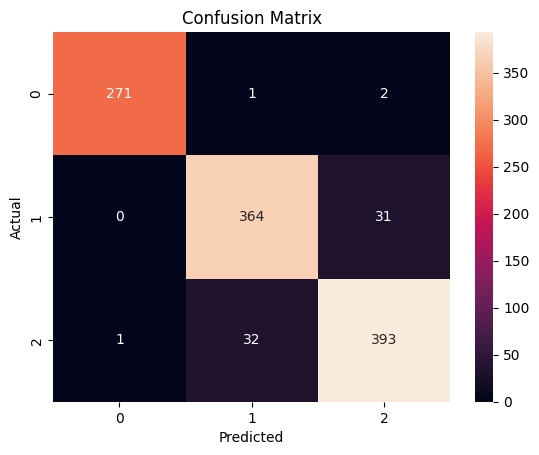

In [80]:
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

true_labels = []
pred_labels = []

gt_dir = "dataset/labels/val"
pred_dir = "runs/detect/val-2/labels" # Corrected path

for file in os.listdir(gt_dir):
    gt_path = f"{gt_dir}/{file}"
    pr_path = f"{pred_dir}/{file}"

    if not os.path.exists(pr_path):
        continue

    with open(gt_path) as f:
        gt = [int(x.split()[0]) for x in f]

    with open(pr_path) as f:
        pr = [int(x.split()[0]) for x in f]

    m = min(len(gt), len(pr))
    true_labels.extend(gt[:m])
    pred_labels.extend(pr[:m])

# Ensure there are labels before creating the confusion matrix
if true_labels and pred_labels:
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
else:
    print("No matching ground truth and predicted labels found to create confusion matrix.")


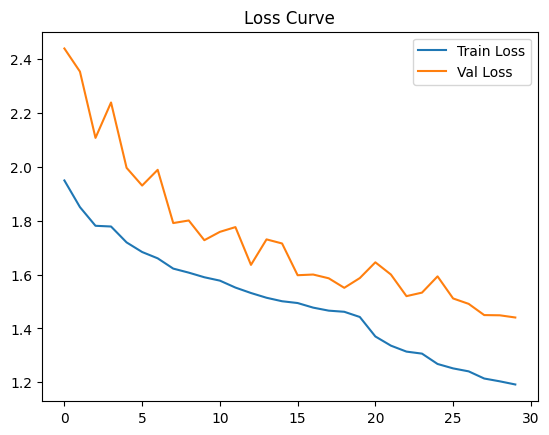

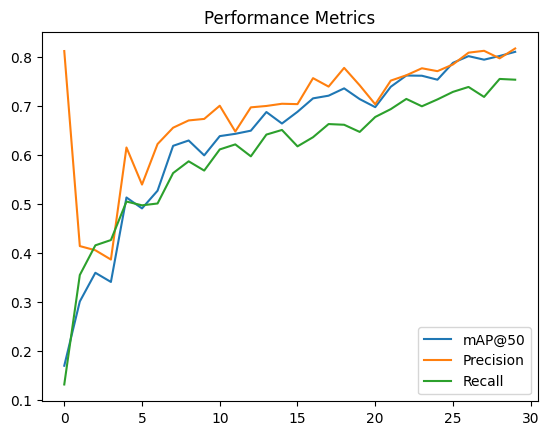

In [81]:
import pandas as pd

results = pd.read_csv("runs/detect/model2/results.csv")

# Loss
plt.figure()
plt.plot(results['train/box_loss'], label="Train Loss")
plt.plot(results['val/box_loss'], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# Metrics
plt.figure()
plt.plot(results['metrics/mAP50(B)'], label="mAP@50")
plt.plot(results['metrics/precision(B)'], label="Precision")
plt.plot(results['metrics/recall(B)'], label="Recall")
plt.legend()
plt.title("Performance Metrics")
plt.show()

In [82]:
!zip -r project.zip runs/detect/model2/weights data.yaml app.py

updating: app.py (deflated 50%)
updating: data.yaml (deflated 22%)
updating: runs/detect/model2/weights/ (stored 0%)
updating: runs/detect/model2/weights/best.pt (deflated 10%)
updating: runs/detect/model2/weights/last.pt


zip error: Interrupted (aborting)
